# **Objective:**
Build and fine-tune a transformer model (BERT/DistilBERT) to perform Part-of-Speech (POS) Tagging and Chunking (Phrase Detection) using token classification techniques.


In [ ]:
!pip install -q transformers datasets evaluate seqeval kagglehub

# Task-1 : Data selection

In [ ]:


import kagglehub
import os
import pandas as pd
from datasets import Dataset, DatasetDict

# Sourcing dataset directly via kagglehub
print("Downloading dataset via kagglehub...")
dataset_path = kagglehub.dataset_download("alaakhaled/conll003-englishversion")
print(f"Dataset downloaded to: {dataset_path}")

# Define file paths dynamically based on the kagglehub download
train_file = os.path.join(dataset_path, "train.txt")
valid_file = os.path.join(dataset_path, "valid.txt")

# Parsing function for CoNLL text format
def load_conll_from_txt(file_path):
    tokens, chunk_tags = [], []
    current_tokens, current_chunks = [], []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line.startswith("-DOCSTART-") or line == "":
                if current_tokens:
                    tokens.append(current_tokens)
                    chunk_tags.append(current_chunks)
                    current_tokens, current_chunks = [], []
            else:
                splits = line.split()
                if len(splits) >= 3:
                    current_tokens.append(splits[0])
                    # In standard CoNLL-2003, Chunk tag is the 3rd column (index 2)
                    current_chunks.append(splits[2])

    # Catch the last sentence if the file doesn't end with a newline
    if current_tokens:
        tokens.append(current_tokens)
        chunk_tags.append(current_chunks)

    return pd.DataFrame({"tokens": tokens, "chunk_tags": chunk_tags})

# Parse the training and validation sets
train_df = load_conll_from_txt(train_file)
valid_df = load_conll_from_txt(valid_file)

# Convert to Hugging Face Dataset format
raw_datasets = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(valid_df)
})

# Identify Label Types (Chunk Tags)

# Extract unique tags from BOTH train and validation sets to avoid KeyErrors
unique_tags_train = set(tag for doc in train_df['chunk_tags'] for tag in doc)
unique_tags_valid = set(tag for doc in valid_df['chunk_tags'] for tag in doc)

# Combine them using a union
unique_tags = unique_tags_train.union(unique_tags_valid)
chunk_tags_list = sorted(list(unique_tags))

# Create the mappings
label2id = {label: i for i, label in enumerate(chunk_tags_list)}
id2label = {i: label for i, label in enumerate(chunk_tags_list)}

print(f"\nDataset Name: CoNLL-2003")
print(f"Categories (Chunk Tags): {chunk_tags_list}")
print(f"Total Unique Tags: {len(chunk_tags_list)}")

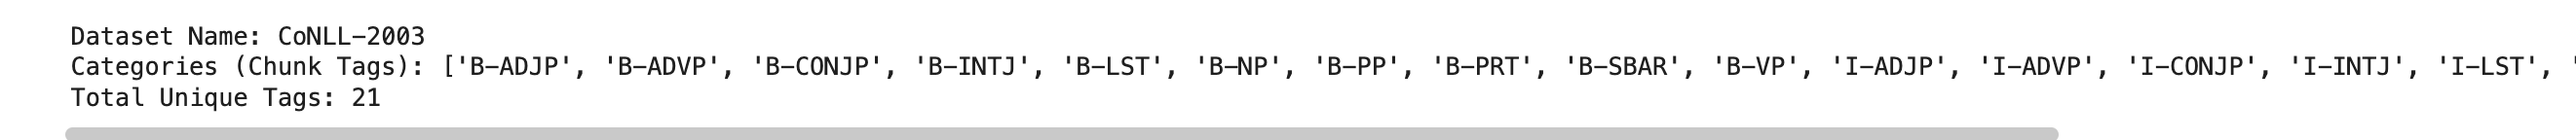

# Task-2 : Data preprocessing

In [ ]:
from transformers import AutoTokenizer

model_checkpoint = "distilbert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=128
    )

    labels = []
    for i, label_list in enumerate(examples["chunk_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            # Set special tokens to -100
            if word_idx is None:
                label_ids.append(-100)
            # Assign the label to the first subword of a token
            elif word_idx != previous_word_idx:
                label_ids.append(label2id[label_list[word_idx]])
            # Assign -100 to subsequent subwords of the same token
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Apply preprocessing
tokenized_datasets = raw_datasets.map(tokenize_and_align_labels, batched=True)

print("Input IDs:", tokenized_datasets["train"][0]["input_ids"])
print("Attention Mask:", tokenized_datasets["train"][0]["attention_mask"])
print("Labels:", tokenized_datasets["train"][0]["labels"])

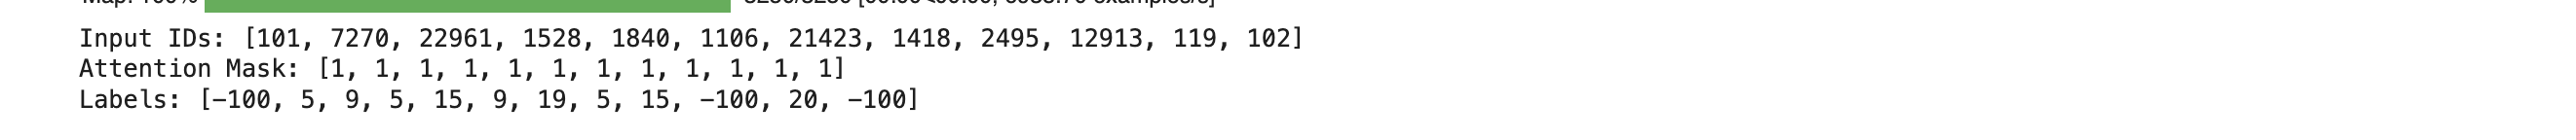

# Task-3 : Model Setup

In [ ]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(chunk_tags_list),
    id2label=id2label,
    label2id=label2id
)

Task 4 & 5 : Training setup and evaluation

In [ ]:
import numpy as np
import evaluate
from transformers import TrainingArguments, Trainer, DataCollatorForTokenClassification

# Load seqeval metric
seqeval = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (-100)
    true_predictions = [
        [chunk_tags_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [chunk_tags_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

# Define Data Collator to dynamically pad sequences
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# Define Training Arguments
args = TrainingArguments(
    output_dir="./distilbert-chunking",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

# Training
trainer.train()

# Evaluation
trainer.evaluate()

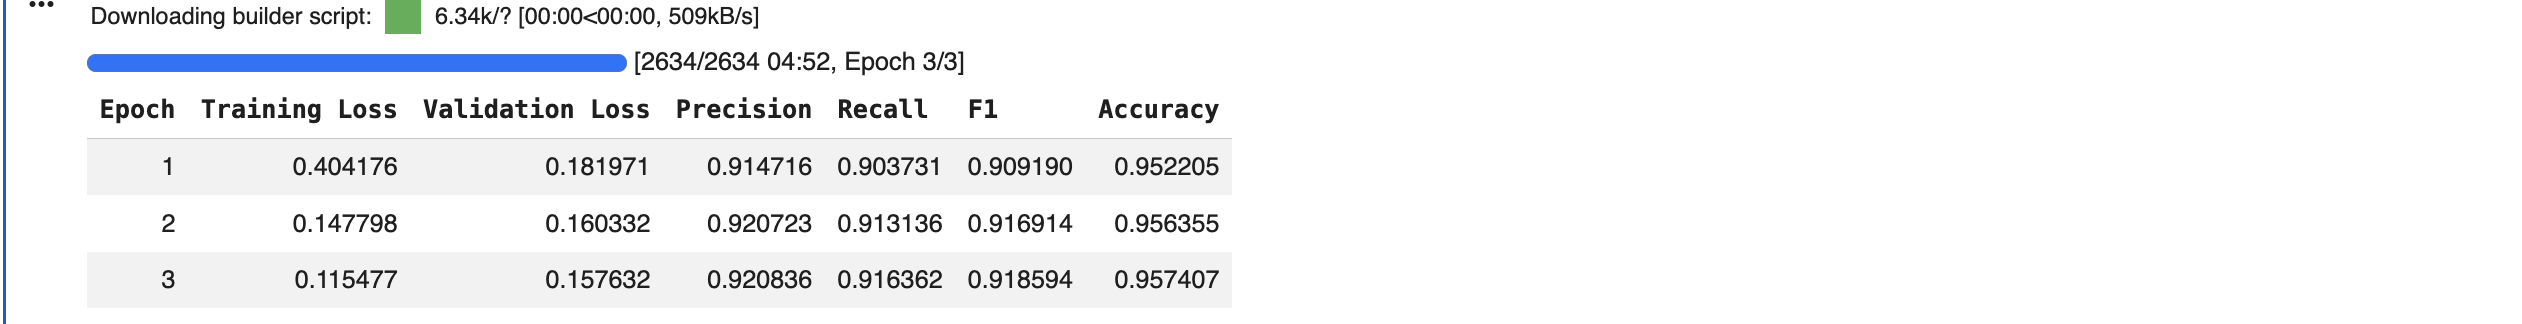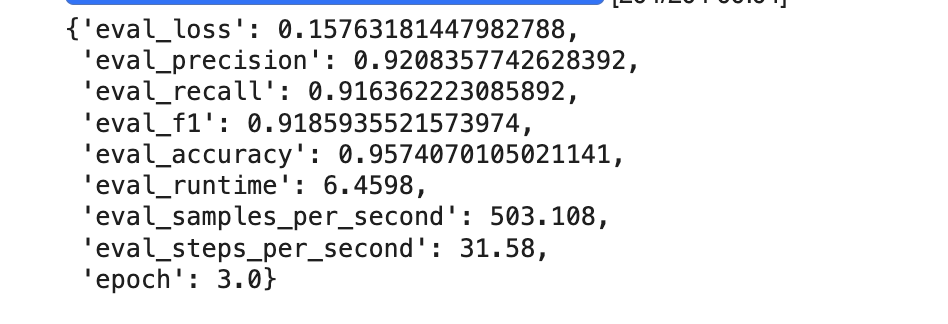

# Task-6 : Inference

In [ ]:
import torch

# Put model in evaluation mode
model.eval()

custom_sentence = "John works at Google in California"
# Tokenize input
inputs = tokenizer(custom_sentence, return_tensors="pt")
# Move inputs to the same device as the model
inputs = {k: v.to(model.device) for k, v in inputs.items()}

# Predict
with torch.no_grad():
    outputs = model(**inputs)

# Get predictions (argmax over the logits)
predictions = torch.argmax(outputs.logits, dim=-1).squeeze().tolist()
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"].squeeze().tolist())

print(f"Input: {custom_sentence}\n")
print(f"{'Token':<15} | {'Chunk Tag'}")
print("-" * 30)

# Print cleanly, ignoring special subword tokens (marked by ##) and CLS/SEP
for token, pred in zip(tokens, predictions):
    if token not in ['[CLS]', '[SEP]'] and not token.startswith("##"):
        print(f"{token:<15} | {id2label[pred]}")

Input: John works at Google in California

Token           | Chunk Tag
------------------------------
John            | B-NP
works           | B-VP
at              | B-PP
Google          | B-NP
in              | B-PP
California      | B-NP


# Task-7

# **Comparison**

**Input Sentence:** "The smart student is reading a book."

**POS Tagging Output (Word-by-Word):**

The $\rightarrow$ DT (Determiner)

smart $\rightarrow$ JJ (Adjective)

student $\rightarrow$ NN (Noun)

is $\rightarrow$ VBZ (Verb)

reading $\rightarrow$ VBG (Verb)

a $\rightarrow$ DT (Determiner)

book $\rightarrow$ NN (Noun)2.

**Chunking Output (Phrase-by-Phrase):**

 [The smart student] $\rightarrow$ Noun Phrase (NP) * (Tags: B-NP, I-NP, I-NP)

 [is reading] $\rightarrow$ Verb Phrase (VP) * (Tags: B-VP, I-VP)

 [a book] $\rightarrow$ Noun Phrase (NP) * (Tags: B-NP, I-NP)

# Task-8

# **1. Differences**

**POS Tagging:** Word-level classification. It assigns a specific grammatical label (e.g., Noun, Verb, Adjective) to every single token individually.

**Chunking:** Phrase-level grouping. It groups consecutive words together into meaningful syntactic units (e.g., Noun Phrase, Verb Phrase) using formats like BIO tags.

# **2. Challenges Faced**

**Subword Tokenization:**  Transformer tokenizers (like BERT) split words into pieces. Aligning the original chunk tags with these new subword tokens (and ignoring special tokens with -100) is complex.

**Dataset Edge Cases:** Handling tags that appear in the validation set but not in the training set (e.g., the I-PRT tag), requiring careful vocabulary mapping.

**Class Imbalance:** The O (Outside) tag heavily dominates the dataset, which can bias the model's accuracy metric if not evaluated properly (why seqeval is necessary).

# **3. Observations and Insights**

**Context is Key:** Chunking is inherently harder than POS tagging because it requires understanding the boundaries of multi-word phrases, not just isolated definitions.

**Transformer Superiority:** Models like DistilBERT excel at sequence tagging because their self-attention mechanisms can look at the entire sentence simultaneously, capturing the deep bidirectional context needed to identify phrase boundaries accurately.